# Lecture 7 — Regression: Fitting a Line to Data

**Practices covered:** L01 (Linear Regression), L02 (Multivariate Linear Regression)

---

## The Core Problem

You have data: city populations and the profit a food truck makes there.
You want to **predict** profit for a new city you've never seen.

This is **regression** — fitting a function to observed data so you can predict continuous outputs.

---

## Part 1 — What are we fitting?

The simplest model: a **straight line**.

$$\hat{y} = w_0 + w_1 \cdot x$$

- $x$ = input (population)
- $\hat{y}$ = predicted output (profit)
- $w_0$ = intercept (bias) — where the line crosses y-axis
- $w_1$ = slope — how much profit changes per unit of population

**Your job:** find the $w_0$ and $w_1$ that make the line fit the data best.

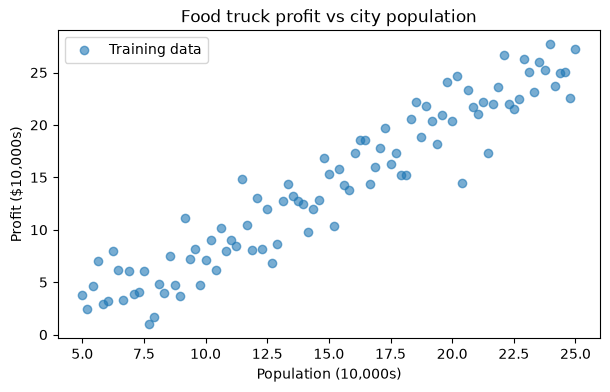

Data: 97 cities, population range 5.0–25.0


In [34]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Synthetic data: population (x) → profit (y)
np.random.seed(42)
x = np.linspace(5, 25, 97)
y = 1.2 * x - 3.5 + 2.5 * np.random.randn(97)  # true line + noise

plt.figure(figsize=(7, 4))
plt.scatter(x, y, alpha=0.6, label='Training data')
plt.xlabel('Population (10,000s)')
plt.ylabel('Profit ($10,000s)')
plt.title('Food truck profit vs city population')
plt.legend()
plt.show()

print(f"Data: {len(x)} cities, population range {x.min():.1f}–{x.max():.1f}")

## Part 2 — The Cost Function: Measuring "How Bad" a Line Is

For any choice of $w_0$ and $w_1$, we can measure how wrong our predictions are.

**Mean Squared Error (MSE):**

$$J(w_0, w_1) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

- $m$ = number of training examples
- $\hat{y}^{(i)} = w_0 + w_1 x^{(i)}$ = our prediction for sample $i$
- $y^{(i)}$ = actual value
- The $\frac{1}{2}$ is just for math convenience when taking derivatives

**Why squared?** Two reasons:
1. It penalizes large errors more than small ones (a $10\times$ bigger error becomes $100\times$ worse cost)
2. It's differentiable everywhere (unlike absolute value), so we can use calculus to minimize it

**The goal:** find $w_0, w_1$ that minimize $J$.

In [35]:
# Normalize x before building the design matrix
x_norm = (x - x.mean()) / x.std(ddof=1)

# Build the design matrix X: column of 1s (for bias) + normalized feature column
m = len(x)
X = np.column_stack((np.ones(m), x_norm))  # shape (97, 2)
Y = y.reshape(m, 1)                         # shape (97, 1)

print("X shape:", X.shape)   # (97, 2)
print("Y shape:", Y.shape)   # (97, 1)
print("\nFirst 3 rows of X (bias=1, then x_normalized):")
print(X[:3])

X shape: (97, 2)
Y shape: (97, 1)

First 3 rows of X (bias=1, then x_normalized):
[[ 1.         -1.7054263 ]
 [ 1.         -1.66989658]
 [ 1.         -1.63436687]]


In [36]:
# Why add the column of 1s?
# h(x) = w0*1 + w1*x  =  [1, x] @ [w0, w1]  =  X @ W
# This lets us write the entire prediction as a single matrix multiply!

def computeCost(X, Y, W):
    """MSE cost. X:(m,n), Y:(m,1), W:(n,1). Returns scalar."""
    m = Y.shape[0]
    error = X @ W - Y          # predictions minus actuals: (m,1)
    C = np.sum(error**2) / (2*m)
    return C

# Test: bad weights → high cost; good weights → low cost
W_bad  = np.array([[0.0], [0.0]])   # predicts 0 for everything
W_good = np.array([[-3.5], [1.2]])  # close to true line

print(f"Cost with zeros:      {computeCost(X, Y, W_bad):.4f}")
print(f"Cost with true params: {computeCost(X, Y, W_good):.4f}")

Cost with zeros:      129.0343
Cost with true params: 177.2165


## Part 3 — Gradient Descent: Sliding Down the Cost Bowl

Imagine $J(w_0, w_1)$ as a bowl-shaped surface. We want to reach the bottom.

**Gradient descent:** take small steps in the direction the surface goes *downhill*.

The direction of steepest descent is given by the **gradient** — the partial derivatives of $J$:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \cdot x_j^{(i)}$$

**Update rule** (simultaneous for all $j$):

$$w_j \leftarrow w_j - \alpha \cdot \frac{\partial J}{\partial w_j}$$

- $\alpha$ = learning rate — how big each step is
- Too large: overshoots, diverges
- Too small: takes forever to converge

In matrix form (vectorized — no Python loops needed):

$$W \leftarrow W - \frac{\alpha}{m} X^T (XW - Y)$$

In [37]:
def gradientDescent(X, Y, W, learning_rate, epochs):
    """
    Run gradient descent for `epochs` steps.
    Returns: final W, cost history
    """
    m = Y.size
    C_history = []
    
    for i in range(epochs):
        # Vectorized gradient: X.T @ (X@W - Y) has shape (n,1)
        # This is equivalent to computing each partial derivative simultaneously
        gradient = X.T @ (X @ W - Y) / m     # (2,97) @ (97,1) = (2,1)
        W = W - learning_rate * gradient
        C_history.append(computeCost(X, Y, W))
    
    return W, np.array(C_history)

# Train
W_init = np.zeros((2, 1))
W_opt, costs = gradientDescent(X, Y, W_init, learning_rate=0.01, epochs=1500)

print(f"Learned w0 (bias): {W_opt[0,0]:.4f}  (true: -3.5)")
print(f"Learned w1 (slope): {W_opt[1,0]:.4f}  (true:  1.2)")
print(f"Final cost: {costs[-1]:.4f}")

Learned w0 (bias): 14.2315  (true: -3.5)
Learned w1 (slope): 7.1284  (true:  1.2)
Final cost: 2.6211


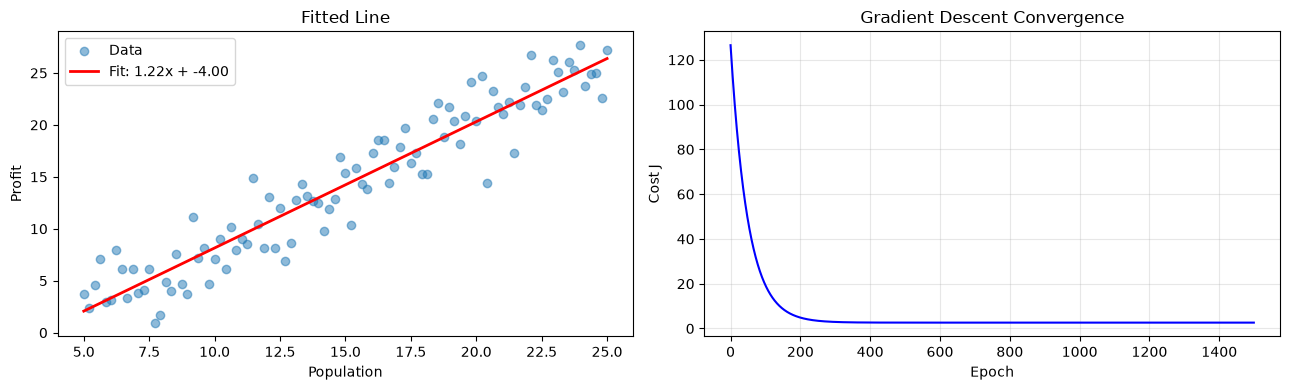

In [38]:
# Visualize: did we find a good line?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: data + fitted line (convert weights back to original x scale for plotting)
x_mu, x_sigma = x.mean(), x.std(ddof=1)
w0_orig = W_opt[0,0] - W_opt[1,0] * x_mu / x_sigma
w1_orig = W_opt[1,0] / x_sigma

x_line = np.linspace(x.min(), x.max(), 100)
y_line = w0_orig + w1_orig * x_line
axes[0].scatter(x, y, alpha=0.5, label='Data')
axes[0].plot(x_line, y_line, 'r-', linewidth=2, label=f'Fit: {w1_orig:.2f}x + {w0_orig:.2f}')
axes[0].set_xlabel('Population'); axes[0].set_ylabel('Profit')
axes[0].set_title('Fitted Line'); axes[0].legend()

# Right: cost over epochs
axes[1].plot(costs, 'b-')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cost J')
axes[1].set_title('Gradient Descent Convergence')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Part 4 — Why the Matrix Formulation?

The gradient formula:

```
gradient = X.T @ (X @ W - Y) / m
```

Let's unpack why this works:

- `X @ W` computes all $m$ predictions at once — shape `(m,1)`
- `X @ W - Y` computes all $m$ errors at once
- `X.T @` then computes $\sum_{i=1}^m \text{error}^{(i)} \cdot x_j^{(i)}$ for **every** $j$ simultaneously

This replaces two nested loops in a single line. This is **vectorization** — the reason NumPy is used instead of pure Python loops.

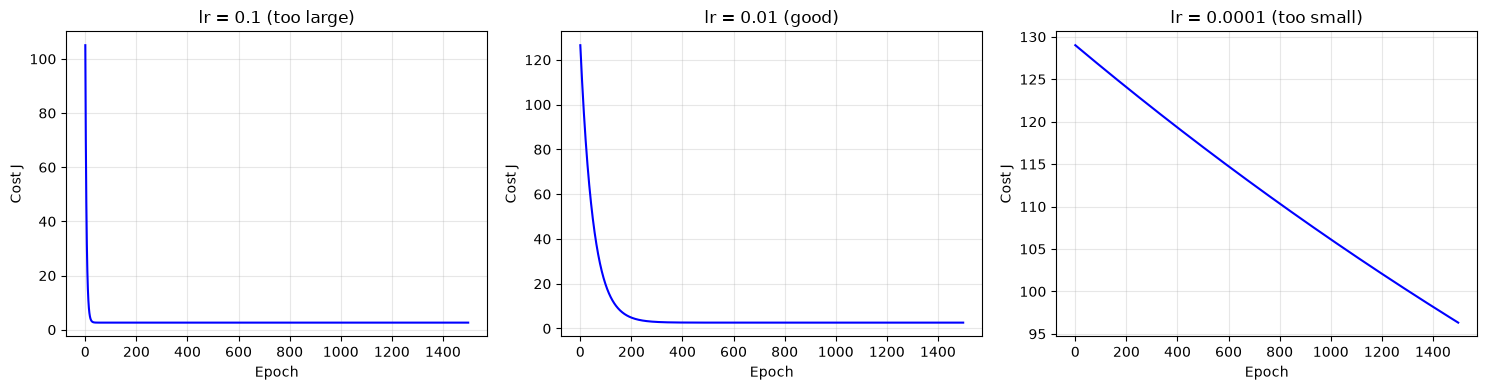

In [39]:
# Why does learning rate matter? Compare 3 rates:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr, label in zip(axes, [0.1, 0.01, 0.0001], ['0.1 (too large)', '0.01 (good)', '0.0001 (too small)']):
    try:
        _, costs_lr = gradientDescent(X, Y, np.zeros((2,1)), lr, 1500)
        if np.any(np.isnan(costs_lr)):
            ax.text(0.5, 0.5, 'DIVERGED (NaN)', transform=ax.transAxes, ha='center')
        else:
            ax.plot(costs_lr, 'b-')
            ax.set_ylabel('Cost J')
    except:
        ax.text(0.5, 0.5, 'DIVERGED', transform=ax.transAxes, ha='center')
    ax.set_title(f'lr = {label}')
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Part 5 — Multivariate Regression: More than One Feature

In practice (L02), you have multiple features: house area, number of rooms → price.

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n = \mathbf{x}^T \mathbf{w}$$

**Nothing changes in the code** — just more columns in $X$. The same `computeCost` and `gradientDescent` work.

**BUT:** feature scales matter. If $x_1$ = area (100–3000 m²) and $x_2$ = rooms (1–5), then a unit change in $x_1$ has 100× the numerical effect of $x_2$. Gradient descent will take long zigzag steps.

**Fix: feature normalization (Z-score)**

$$x_j \leftarrow \frac{x_j - \mu_j}{\sigma_j}$$

After this, every feature has mean 0 and standard deviation 1. Gradient descent converges much faster.

In [40]:
# Multivariate example: area + rooms → price
np.random.seed(0)
m2 = 47
area  = np.random.uniform(500, 3000, m2)   # m² — large scale
rooms = np.random.randint(1, 6, m2).astype(float)  # 1–5 rooms — small scale
price = 200*area + 50000*rooms - 30000 + 10000*np.random.randn(m2)

X2_raw = np.column_stack((area, rooms))

print("Without normalization:")
print(f"  area:  mean={area.mean():.0f}, std={area.std():.0f}")
print(f"  rooms: mean={rooms.mean():.1f}, std={rooms.std():.2f}")
print("  → ratio of scales:", area.std() / rooms.std())

Without normalization:
  area:  mean=1888, std=677
  rooms: mean=3.2, std=1.37
  → ratio of scales: 495.0338034126781


In [41]:
def featureNormalize(X):
    """Z-score normalization. Returns (X_norm, mu, sigma)."""
    mu    = np.mean(X, axis=0)           # shape (n,)
    sigma = np.std(X, axis=0, ddof=1)    # ddof=1 = sample std (as used in practice)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X2_norm, mu2, sigma2 = featureNormalize(X2_raw)

print("After normalization:")
print(f"  area:  mean={X2_norm[:,0].mean():.2f}, std={X2_norm[:,0].std():.2f}")
print(f"  rooms: mean={X2_norm[:,1].mean():.2f}, std={X2_norm[:,1].std():.2f}")

# Add bias column
X2 = np.column_stack((np.ones(m2), X2_norm))
Y2 = price.reshape(m2, 1)

After normalization:
  area:  mean=-0.00, std=0.99
  rooms: mean=-0.00, std=0.99


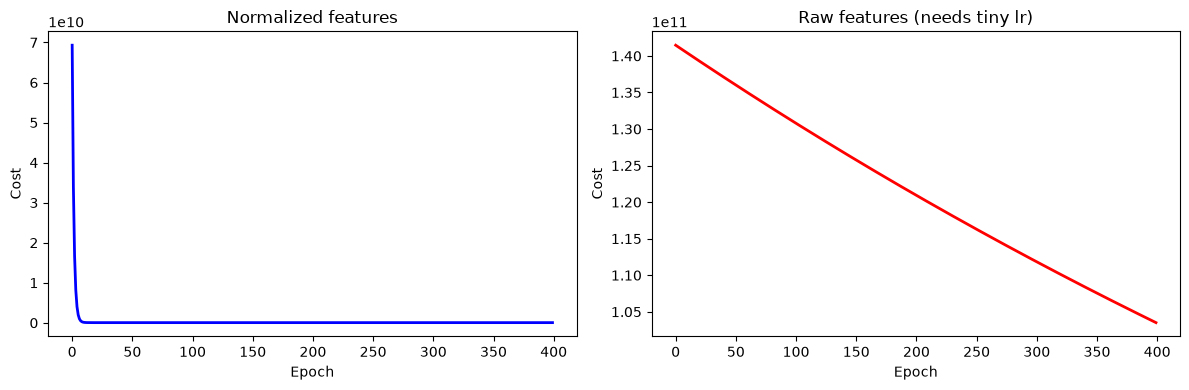

Normalized final cost: 4.57e+07
Raw final cost:        1.04e+11


In [42]:
# Compare convergence: normalized vs raw features
_, costs_norm = gradientDescent(X2, Y2, np.zeros((3,1)), 0.3, 400)

X2_raw_bias = np.column_stack((np.ones(m2), X2_raw))
# Very small lr needed for raw data (otherwise diverges)
_, costs_raw = gradientDescent(X2_raw_bias, Y2, np.zeros((3,1)), 1e-10, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(costs_norm, 'b-', linewidth=2)
axes[0].set_title('Normalized features'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cost')
axes[1].plot(costs_raw, 'r-', linewidth=2)
axes[1].set_title('Raw features (needs tiny lr)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cost')
plt.tight_layout(); plt.show()
print(f"Normalized final cost: {costs_norm[-1]:.2e}")
print(f"Raw final cost:        {costs_raw[-1]:.2e}")

## Part 6 — Regularization: Preventing Overfitting

What if we have too many features and the model memorizes the training data instead of generalizing?

**Overfitting:** the model perfectly fits training data but fails on new data.

**Fix: add a penalty for large weights to the cost function (Ridge regression)**

$$J_{\text{reg}}(W) = \frac{1}{2m}\sum(\hat{y}^{(i)} - y^{(i)})^2 + \frac{\lambda}{2m}\sum_{j=1}^{n} w_j^2$$

- $\lambda$ (lambda) controls the tradeoff: $\lambda=0$ = no regularization, $\lambda=\infty$ = all weights → 0
- We **do not** penalize $w_0$ (the bias), only $w_1, \ldots, w_n$
- Large weights are penalized → model forced to stay simple

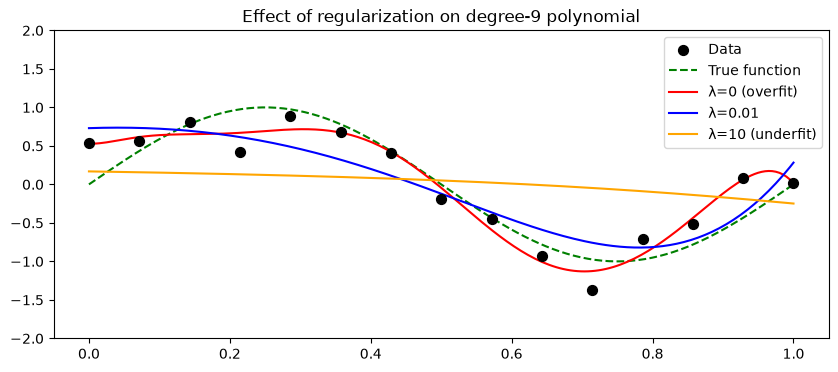

In [43]:
# Illustrate: polynomial fit with and without regularization
np.random.seed(3)
x_small = np.linspace(0, 1, 15)
y_small = np.sin(2*np.pi*x_small) + 0.3*np.random.randn(15)

# Build degree-9 polynomial features
def poly_features(x, degree):
    return np.column_stack([x**i for i in range(degree+1)])

X_poly = poly_features(x_small, degree=9)
Y_poly = y_small.reshape(-1,1)

def ridge_solution(X, Y, lam):
    n = X.shape[1]
    I = np.eye(n); I[0,0] = 0  # don't regularize bias
    return np.linalg.inv(X.T @ X + lam * I) @ X.T @ Y

x_plot = np.linspace(0, 1, 200)
plt.figure(figsize=(10, 4))
plt.scatter(x_small, y_small, c='black', zorder=5, s=50, label='Data')
plt.plot(x_plot, np.sin(2*np.pi*x_plot), 'g--', label='True function')

for lam, color, label in [(0, 'red', 'λ=0 (overfit)'),
                           (0.01, 'blue', 'λ=0.01'),
                           (10, 'orange', 'λ=10 (underfit)')]:
    W_poly = ridge_solution(X_poly, Y_poly, lam)
    y_plot = poly_features(x_plot, 9) @ W_poly
    plt.plot(x_plot, y_plot, color=color, linewidth=1.5, label=label)

plt.ylim(-2, 2); plt.legend(); plt.title('Effect of regularization on degree-9 polynomial')
plt.show()

## Part 7 — The Normal Equation (Closed-form Solution)

For linear regression, there's an exact formula — no iteration needed:

$$W^* = (X^T X)^{-1} X^T Y$$

**When to use gradient descent vs normal equation:**

| | Gradient Descent | Normal Equation |
|---|---|---|
| Need to choose $\alpha$ | Yes | No |
| Scales to large $n$ | Yes | No ($O(n^3)$ matrix inversion) |
| Works for all models | Yes (logistic, neural nets, etc.) | Only linear regression |
| In practice | Used for most ML | Only for small linear problems |

The normal equation is good for understanding, but **gradient descent is what the exam notebooks use**.

In [44]:
# Normal equation: exact solution (X already uses normalized x)
W_exact = np.linalg.inv(X.T @ X) @ X.T @ Y

# Both sets of weights are in normalized space — convert to original scale to compare
x_mu, x_sigma = x.mean(), x.std(ddof=1)
w0_gd    = W_opt[0,0]   - W_opt[1,0]   * x_mu / x_sigma
w1_gd    = W_opt[1,0]   / x_sigma
w0_exact = W_exact[0,0] - W_exact[1,0] * x_mu / x_sigma
w1_exact = W_exact[1,0] / x_sigma

print(f"Normal equation: w0={w0_exact:.4f}, w1={w1_exact:.4f}")
print(f"Gradient descent: w0={w0_gd:.4f}, w1={w1_gd:.4f}")
print("They should be very close!")

Normal equation: w0=-4.0038, w1=1.2157
Gradient descent: w0=-4.0038, w1=1.2157
They should be very close!


---
## Summary: What You Need to Know for the Exam

**Key concepts:**
- Regression = predict continuous output from input features
- MSE cost $J = \frac{1}{2m}\|XW - Y\|^2$ — measures how wrong our predictions are
- Gradient descent iteratively minimizes $J$ by following the slope downhill
- Feature normalization is required when features have different scales
- Regularization (add $\lambda \|W\|^2$ to cost) prevents overfitting

**Key code patterns from the practices:**
```python
# Add bias column
X = np.column_stack((np.ones(m), x))    # (m, 2)

# Cost
error = X @ W - Y
J = np.sum(error**2) / (2*m)

# Gradient (vectorized)
gradient = X.T @ (X @ W - Y) / m
W = W - lr * gradient

# Feature normalize
X_norm = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
```

**Next:** [L08_bayesian_regression.ipynb](L08_bayesian_regression.ipynb) — the Bayesian view of regression and why regularization is actually a prior belief.

---
## Exercises

### Exercise 1
The current `gradientDescent` uses a vectorized gradient. Rewrite it with explicit partial derivatives (two separate sums for $w_0$ and $w_1$) and verify you get the same result.

In [ ]:
def gradientDescent_explicit(X, Y, W, learning_rate, epochs):
    m = Y.size
    C_history = []
    for i in range(epochs):
        new_W = np.zeros((2, 1))
        # YOUR CODE HERE
        # new_W[0] = W[0] - (learning_rate/m) * ...
        # new_W[1] = W[1] - (learning_rate/m) * ...
        W = new_W.copy()
        C_history.append(computeCost(X, Y, W))
    return W, np.array(C_history)

# Should match W_opt from above
W_test, _ = gradientDescent_explicit(X, Y, np.zeros((2,1)), 0.01, 1500)
print(f"Explicit: w0={W_test[0,0]:.4f}, w1={W_test[1,0]:.4f}")
print(f"Vectorized: w0={W_opt[0,0]:.4f}, w1={W_opt[1,0]:.4f}")

In [ ]:
# SOLUTION
def gradientDescent_explicit(X, Y, W, learning_rate, epochs):
    m = Y.size
    C_history = []
    for i in range(epochs):
        new_W = np.zeros((2, 1))
        error = X @ W - Y                                        # (m,1)
        new_W[0] = W[0] - (learning_rate/m) * np.sum(error)     # ∂J/∂w0: x0=1 always
        new_W[1] = W[1] - (learning_rate/m) * np.sum(error * X[:, 1:2])  # ∂J/∂w1
        W = new_W.copy()
        C_history.append(computeCost(X, Y, W))
    return W, np.array(C_history)

W_test, _ = gradientDescent_explicit(X, Y, np.zeros((2,1)), 0.01, 1500)
print(f"Explicit:  w0={W_test[0,0]:.4f}, w1={W_test[1,0]:.4f}")
print(f"Vectorized: w0={W_opt[0,0]:.4f}, w1={W_opt[1,0]:.4f}")

### Exercise 2
Use the multivariate model to predict the price of a house with 1500 m² and 3 rooms.
Remember: you must normalize using the **training** mu and sigma.

In [ ]:
W2_opt, _ = gradientDescent(X2, Y2, np.zeros((3,1)), 0.3, 400)

def predict_price(area_m2, num_rooms, mu, sigma, W):
    # YOUR CODE HERE
    # Normalize the input using training mu and sigma
    # Add bias column
    # Multiply by W
    pass

price = predict_price(1500, 3, mu2, sigma2, W2_opt)
print(f"Predicted price: {price:.0f}")

In [ ]:
# SOLUTION
def predict_price(area_m2, num_rooms, mu, sigma, W):
    x_raw = np.array([area_m2, num_rooms])
    x_norm = (x_raw - mu) / sigma
    x_input = np.array([1.0, x_norm[0], x_norm[1]])  # add bias
    return float(x_input @ W)

price = predict_price(1500, 3, mu2, sigma2, W2_opt)
print(f"Predicted price for 1500m², 3 rooms: {price:.0f}")